# EDA 009: Split validation (hybrid temporal + sparse random)

This notebook validates the split contract used by `scripts/split_reviews.py` when `split_mode = hybrid_user_temporal`:

- users with `< sparse_user_threshold` interactions use deterministic random split (`sparse_random_*` ratios)
- users with `>= sparse_user_threshold` interactions use per-user last-N temporal assignment

Core checks:

1. `review_id` overlap across splits (must be zero)
2. split timestamp range summaries and quantiles
3. per-user temporal ordering sanity for dense users (`max(train_ts) <= min(val_ts) <= min(test_ts)` where present)
4. coverage diagnostics (users/items across splits)
5. cohort-segmented summaries (`<3` vs `>=3` interactions)


In [1]:
from __future__ import annotations

from pathlib import Path
import json
import numpy as np
import pandas as pd

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 220)


def _repo_root() -> Path:
    here = Path.cwd().resolve()
    for d in [here, *here.parents]:
        if (d / "pyproject.toml").is_file():
            return d
    raise RuntimeError(f"Could not find repo root from cwd={here}")


REPO_ROOT = _repo_root()
CFG_PATH = REPO_ROOT / "configs" / "split_reviews.json"
cfg = json.loads(CFG_PATH.read_text(encoding="utf-8"))

TRAIN_PATH = REPO_ROOT / cfg["train_output_path"]
VAL_PATH = REPO_ROOT / cfg["val_output_path"]
TEST_PATH = REPO_ROOT / cfg["test_output_path"]

USER_COL = cfg.get("user_col", "author.steamid")
TS_COL = cfg.get("timestamp_col", "timestamp_created")
RID_COL = "review_id"
APP_COL = "app_id"
REC_COL = "recommended"
SPARSE_THRESHOLD = int(cfg.get("sparse_user_threshold", 3))

for p in (TRAIN_PATH, VAL_PATH, TEST_PATH):
    if not p.is_file():
        raise FileNotFoundError(p)

usecols = [RID_COL, USER_COL, APP_COL, TS_COL, REC_COL]
train = pd.read_parquet(TRAIN_PATH, columns=usecols).assign(split="train")
val = pd.read_parquet(VAL_PATH, columns=usecols).assign(split="val")
test = pd.read_parquet(TEST_PATH, columns=usecols).assign(split="test")
all_df = pd.concat([train, val, test], ignore_index=True)
all_df[TS_COL] = pd.to_numeric(all_df[TS_COL], errors="coerce")

print(f"Config split_mode={cfg.get('split_mode', 'random_stratified')}")
print(f"Rows train/val/test = {len(train):,} / {len(val):,} / {len(test):,}")

# 1) review_id overlap
ids_train, ids_val, ids_test = set(train[RID_COL]), set(val[RID_COL]), set(test[RID_COL])
overlap_tv = len(ids_train & ids_val)
overlap_tt = len(ids_train & ids_test)
overlap_vt = len(ids_val & ids_test)
print("Overlap review_id train∩val/train∩test/val∩test:", overlap_tv, overlap_tt, overlap_vt)
assert overlap_tv == 0 and overlap_tt == 0 and overlap_vt == 0, "Split leakage: review_id overlap detected"

# 2) timestamp range summaries
def ts_summary(df: pd.DataFrame, name: str) -> pd.Series:
    s = pd.to_numeric(df[TS_COL], errors="coerce")
    return pd.Series(
        {
            "split": name,
            "n_rows": len(df),
            "min_ts": float(np.nanmin(s)) if len(df) else np.nan,
            "p25_ts": float(np.nanquantile(s, 0.25)) if len(df) else np.nan,
            "median_ts": float(np.nanmedian(s)) if len(df) else np.nan,
            "p75_ts": float(np.nanquantile(s, 0.75)) if len(df) else np.nan,
            "max_ts": float(np.nanmax(s)) if len(df) else np.nan,
            "recommended_rate": float(pd.to_numeric(df[REC_COL], errors="coerce").mean()) if len(df) else np.nan,
        }
    )

display(pd.DataFrame([ts_summary(train, "train"), ts_summary(val, "val"), ts_summary(test, "test")]))

# 3) dense-user temporal ordering sanity
user_counts = all_df.groupby(USER_COL)[RID_COL].count().rename("n_interactions")
all_df = all_df.merge(user_counts, left_on=USER_COL, right_index=True, how="left")
all_df["cohort"] = np.where(all_df["n_interactions"] < SPARSE_THRESHOLD, "sparse_lt3", "dense_gte3")

dense = all_df[all_df["cohort"] == "dense_gte3"].copy()

if len(dense) > 0:
    grp = dense.groupby([USER_COL, "split"])[TS_COL].agg(["min", "max"]).reset_index()
    pivot_min = grp.pivot(index=USER_COL, columns="split", values="min")
    pivot_max = grp.pivot(index=USER_COL, columns="split", values="max")

    dense_train_val_violation = int(((pivot_max.get("train") > pivot_min.get("val")) & pivot_min.get("val").notna()).sum())
    dense_val_test_violation = int(((pivot_max.get("val") > pivot_min.get("test")) & pivot_min.get("test").notna()).sum())

    print("Dense-user ordering violations train->val:", dense_train_val_violation)
    print("Dense-user ordering violations val->test:", dense_val_test_violation)

# 4) coverage diagnostics
coverage = pd.DataFrame(
    {
        "split": ["train", "val", "test"],
        "rows": [len(train), len(val), len(test)],
        "unique_users": [train[USER_COL].nunique(), val[USER_COL].nunique(), test[USER_COL].nunique()],
        "unique_items": [train[APP_COL].nunique(), val[APP_COL].nunique(), test[APP_COL].nunique()],
    }
)
display(coverage)

train_users = set(train[USER_COL])
train_items = set(train[APP_COL])
val_user_in_train = float(val[USER_COL].isin(train_users).mean()) if len(val) else np.nan
test_user_in_train = float(test[USER_COL].isin(train_users).mean()) if len(test) else np.nan
val_item_in_train = float(val[APP_COL].isin(train_items).mean()) if len(val) else np.nan
test_item_in_train = float(test[APP_COL].isin(train_items).mean()) if len(test) else np.nan
print(f"User-in-train coverage val/test: {val_user_in_train:.4f} / {test_user_in_train:.4f}")
print(f"Item-in-train coverage val/test: {val_item_in_train:.4f} / {test_item_in_train:.4f}")

# 5) cohort-segmented diagnostics
cohort_summary = (
    all_df.groupby(["split", "cohort"]) 
    .agg(
        rows=(RID_COL, "count"),
        unique_users=(USER_COL, "nunique"),
        unique_items=(APP_COL, "nunique"),
        recommended_rate=(REC_COL, "mean"),
        median_ts=(TS_COL, "median"),
    )
    .reset_index()
)
display(cohort_summary)


Config split_mode=support_aware_user_temporal
Rows train/val/test = 5,587,016 / 1,787,471 / 1,786,005
Overlap review_id train∩val/train∩test/val∩test: 0 0 0


,split,n_rows,min_ts,p25_ts,median_ts,p75_ts,max_ts,recommended_rate
0,train,5587016,1.290198e+09,1.480166e+09,1.542142e+09,1.582410e+09,1.611425e+09,0.884908
1,val,1787471,1.290232e+09,1.527836e+09,1.577542e+09,1.598579e+09,1.611425e+09,0.892209
2,test,1786005,1.290276e+09,1.527921e+09,1.577570e+09,1.598587e+09,1.611425e+09,0.891793


Dense-user ordering violations train->val: 0
Dense-user ordering violations val->test: 0


,split,rows,unique_users,unique_items
0,train,5587016,4089647,315
1,val,1787471,1367394,315
2,test,1786005,1366326,315


User-in-train coverage val/test: 0.7150 / 0.7147
Item-in-train coverage val/test: 1.0000 / 1.0000


,split,cohort,rows,unique_users,unique_items,recommended_rate,median_ts
0,test,dense_gte3,830957,411278,315,0.884451,1.580328e+09
1,test,sparse_lt3,955048,955048,315,0.898181,1.575395e+09
2,train,dense_gte3,2320384,823015,314,0.867361,1.517620e+09
3,train,sparse_lt3,3266632,3266632,315,0.897372,1.561952e+09
4,val,dense_gte3,831814,411737,315,0.885271,1.580234e+09
5,val,sparse_lt3,955657,955657,314,0.898247,1.575388e+09


In [2]:
import pandas as pd
import pyarrow.parquet as pq

cleaned_reviews_path = "../../data/interim/steam_reviews_cleaned_english_train.parquet"

pf = pq.ParquetFile(cleaned_reviews_path)
n_groups = min(5, pf.metadata.num_row_groups)   # in case file has fewer than 10
table = pf.read_row_groups(range(n_groups))
df = table.to_pandas()
df.shape

(325073, 21)

In [3]:
# don't limit the number of columns shown in pandas
pd.set_option('display.max_columns', None)


In [4]:
table

pyarrow.Table
review_id: int64
app_id: int64
app_name: large_string
author.steamid: int64
language: large_string
review: large_string
recommended: int64
votes_helpful: int64
author.num_games_owned: int64
author.num_reviews: int64
author.playtime_last_two_weeks: double
author.playtime_at_review: double
steam_purchase: int64
received_for_free: int64
written_during_early_access: int64
timestamp_created: int64
author.last_played: double
is_helpful: int64
review_word_count: int64
review_length_chars: int64
review_age_seconds: double
----
review_id: [[85184605,85184171,85180436,85177892,85174737,...,33760230,33759986,33759538,33759501,33759272]]
app_id: [[292030,292030,292030,292030,292030,...,4000,4000,4000,4000,4000]]
app_name: [["The Witcher 3: Wild Hunt","The Witcher 3: Wild Hunt","The Witcher 3: Wild Hunt","The Witcher 3: Wild Hunt","The Witcher 3: Wild Hunt",...,"Garry's Mod","Garry's Mod","Garry's Mod","Garry's Mod","Garry's Mod"]]
author.steamid: [[76561199054755373,76561198170193529

In [5]:
df.shape

(325073, 21)

Number of games with less than 100 reviews: 2
Number of games with less than 500 reviews: 15


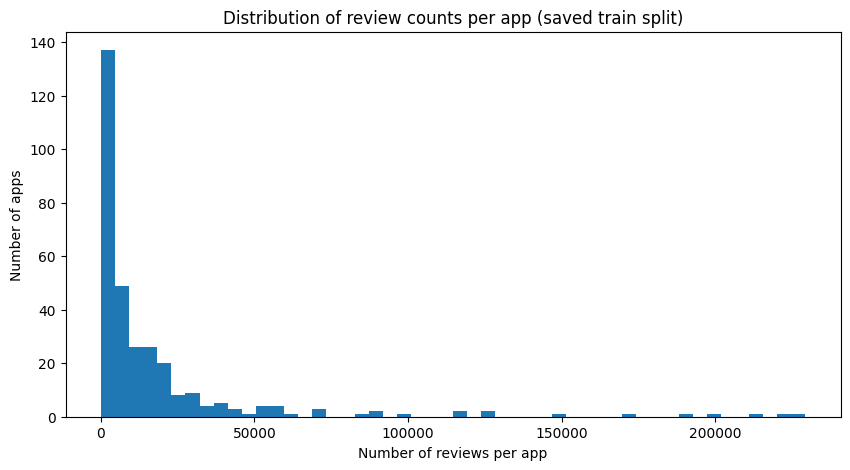

In [6]:
import matplotlib.pyplot as plt

# Saved modeling train split (same artifact as `notebooks/models/tabular/model_000_*` notebooks).
# `df` in the cells below is only a small row-group slice of the full cleaned parquet.
train_path = "../../data/interim/steam_reviews_cleaned_english_train.parquet"
train_split_df = pd.read_parquet(train_path)

app_review_counts = train_split_df["app_name"].value_counts()
num_games_lt_100 = (app_review_counts < 100).sum()
num_games_lt_500 = (app_review_counts < 500).sum()
print(f"Number of games with less than 100 reviews: {num_games_lt_100}")
print(f"Number of games with less than 500 reviews: {num_games_lt_500}")

app_review_counts.plot(
    kind="hist",
    bins=50,
    figsize=(10, 5),
    title="Distribution of review counts per app (saved train split)",
)
plt.xlabel("Number of reviews per app")
plt.ylabel("Number of apps")
plt.show()

In [7]:
df.head()

,review_id,app_id,app_name,author.steamid,language,review,recommended,votes_helpful,author.num_games_owned,author.num_reviews,author.playtime_last_two_weeks,author.playtime_at_review,steam_purchase,received_for_free,written_during_early_access,timestamp_created,author.last_played,is_helpful,review_word_count,review_length_chars,review_age_seconds
0,85184605,292030,The Witcher 3: Wild Hunt,76561199054755373,english,"One of the best RPG's of all time, worthy of a...",1,0,5,3,3200.0,5524.0,1,0,0,1611379970,1.611384e+09,0,12,59,44736.0
1,85184171,292030,The Witcher 3: Wild Hunt,76561198170193529,english,"good story, good graphics. lots to do.",1,0,11,1,823.0,823.0,1,0,0,1611379264,1.611379e+09,0,7,38,45442.0
2,85180436,292030,The Witcher 3: Wild Hunt,76561198065591528,english,favorite game of all time cant wait for the Ne...,1,0,33,1,177.0,23329.0,1,0,0,1611373086,1.611219e+09,0,11,59,51620.0
3,85177892,292030,The Witcher 3: Wild Hunt,76561198040190687,english,"Very Fun, Would play again!",1,0,54,1,75.0,20092.0,1,0,0,1611369121,1.611374e+09,0,5,27,55585.0
4,85174737,292030,The Witcher 3: Wild Hunt,76561199001673284,english,The only thing bigger than the world map is ur...,1,0,111,11,0.0,8068.0,1,0,0,1611364088,1.597494e+09,0,11,50,60618.0


In [8]:
import plotly.express as px

# Create a DataFrame with just the columns of interest and count the combinations
combo_counts = (
    df.groupby(["app_name", "recommended", "is_helpful"])
      .size()
      .reset_index(name="count")
)

# See how many unique combinations exist
num_combos = combo_counts.shape[0]
print(f"Number of unique (app_name, recommended, is_helpful) combinations: {num_combos}")

# Show histogram: how many times does each combination occur?
fig = px.histogram(
    combo_counts,
    x="count",
    nbins=50,
    title="Histogram of Combination Counts (app_name, recommended, is_helpful)",
    labels={"count": "Number of Occurrences"},
)
fig.show()

# Optionally: Display the most frequent combinations
display(combo_counts.sort_values("count", ascending=False).head(10))
display(combo_counts.sort_values("count", ascending=True).head(10))

Number of unique (app_name, recommended, is_helpful) combinations: 28


,app_name,recommended,is_helpful,count
6,Garry's Mod,1,0,86490
22,The Witcher 3: Wild Hunt,1,0,59556
18,Portal 2,1,0,54901
23,The Witcher 3: Wild Hunt,1,1,28107
2,Counter-Strike: Source,1,0,18855
7,Garry's Mod,1,1,18541
19,Portal 2,1,1,14645
10,Half-Life,1,0,12336
3,Counter-Strike: Source,1,1,8317
14,Half-Life 2: Episode Two,1,0,4990


,app_name,recommended,is_helpful,count
12,Half-Life 2: Episode Two,0,0,84
26,X Rebirth,1,0,211
16,Portal 2,0,0,213
13,Half-Life 2: Episode Two,0,1,232
8,Half-Life,0,0,262
24,X Rebirth,0,0,300
9,Half-Life,0,1,385
20,The Witcher 3: Wild Hunt,0,0,462
17,Portal 2,0,1,543
1,Counter-Strike: Source,0,1,559


In [9]:
# Stratified sampling to split the data by ("app_name", "recommended", "is_helpful")
from sklearn.model_selection import train_test_split

# Add a column that combines the three stratification keys
df["stratify_group"] = df.apply(lambda row: f"{row['app_name']}|{row['recommended']}|{row['is_helpful']}", axis=1)

# Note: Some groups may be very small; consider filtering/merging rare groups for "real" splits

# First, split into train+val and test sets (stratified)
train_val_df, test_df = train_test_split(
    df,
    test_size=0.2,
    random_state=42,
    stratify=df["stratify_group"]
)

# Now split train_val into train and validation sets (stratified)
train_df, val_df = train_test_split(
    train_val_df,
    test_size=0.25,  # 0.25 x 0.8 = 0.2 of original data (so 60/20/20 split)
    random_state=42,
    stratify=train_val_df["stratify_group"]
)

print(f"Train shape: {train_df.shape}")
print(f"Validation shape: {val_df.shape}")
print(f"Test shape: {test_df.shape}")

# Clean up temporary column if desired
df.drop(columns=["stratify_group"], inplace=True)
train_df = train_df.drop(columns=["stratify_group"])
val_df = val_df.drop(columns=["stratify_group"])
test_df = test_df.drop(columns=["stratify_group"])

Train shape: (195043, 22)
Validation shape: (65015, 22)
Test shape: (65015, 22)


In [10]:
# Confirm stratification is preserved in the sample splits
def show_group_counts(df, label):
    combo_counts = (
        df.groupby(["app_name", "recommended", "is_helpful"])
          .size()
          .reset_index(name="count")
    )
    print(f"\nTop groups in {label} set:")
    display(combo_counts.sort_values("count", ascending=False).head(10))

show_group_counts(train_df, "train")
show_group_counts(val_df, "validation")
show_group_counts(test_df, "test")


Top groups in train set:


,app_name,recommended,is_helpful,count
6,Garry's Mod,1,0,51894
22,The Witcher 3: Wild Hunt,1,0,35734
18,Portal 2,1,0,32941
23,The Witcher 3: Wild Hunt,1,1,16864
2,Counter-Strike: Source,1,0,11313
7,Garry's Mod,1,1,11125
19,Portal 2,1,1,8787
10,Half-Life,1,0,7402
3,Counter-Strike: Source,1,1,4990
14,Half-Life 2: Episode Two,1,0,2994



Top groups in validation set:


,app_name,recommended,is_helpful,count
6,Garry's Mod,1,0,17298
22,The Witcher 3: Wild Hunt,1,0,11911
18,Portal 2,1,0,10980
23,The Witcher 3: Wild Hunt,1,1,5621
2,Counter-Strike: Source,1,0,3771
7,Garry's Mod,1,1,3708
19,Portal 2,1,1,2929
10,Half-Life,1,0,2467
3,Counter-Strike: Source,1,1,1664
14,Half-Life 2: Episode Two,1,0,998



Top groups in test set:


,app_name,recommended,is_helpful,count
6,Garry's Mod,1,0,17298
22,The Witcher 3: Wild Hunt,1,0,11911
18,Portal 2,1,0,10980
23,The Witcher 3: Wild Hunt,1,1,5622
2,Counter-Strike: Source,1,0,3771
7,Garry's Mod,1,1,3708
19,Portal 2,1,1,2929
10,Half-Life,1,0,2467
3,Counter-Strike: Source,1,1,1663
14,Half-Life 2: Episode Two,1,0,998


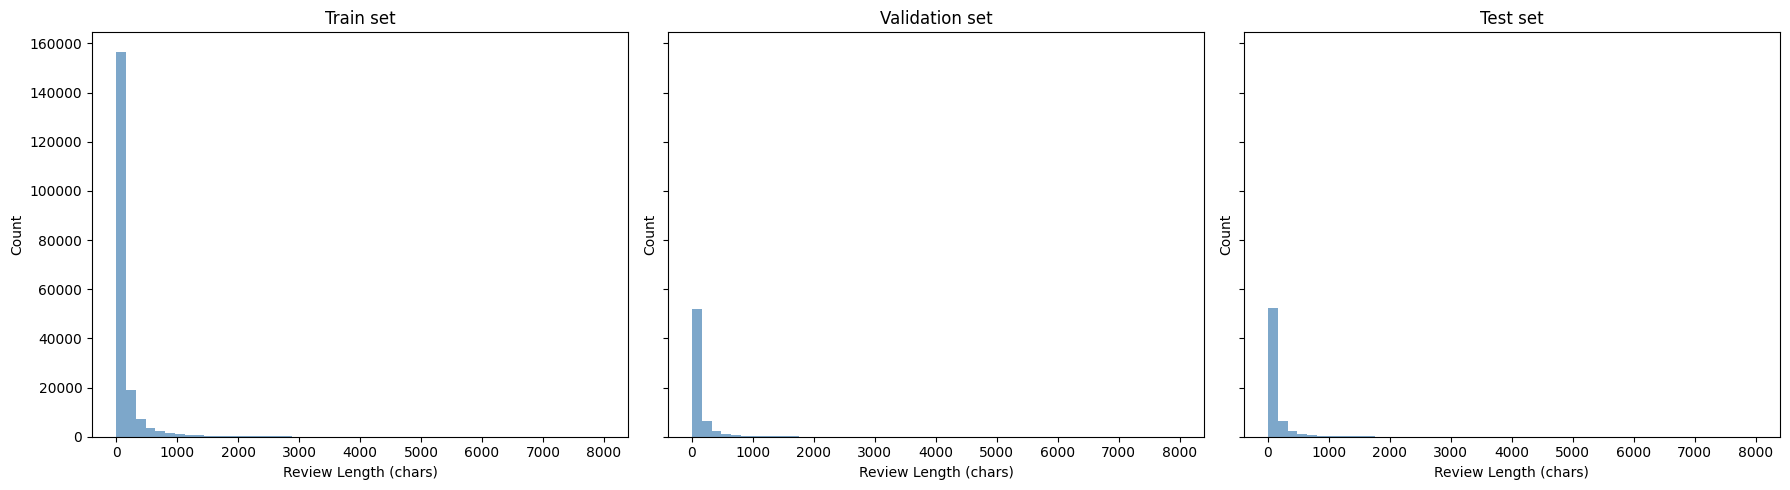

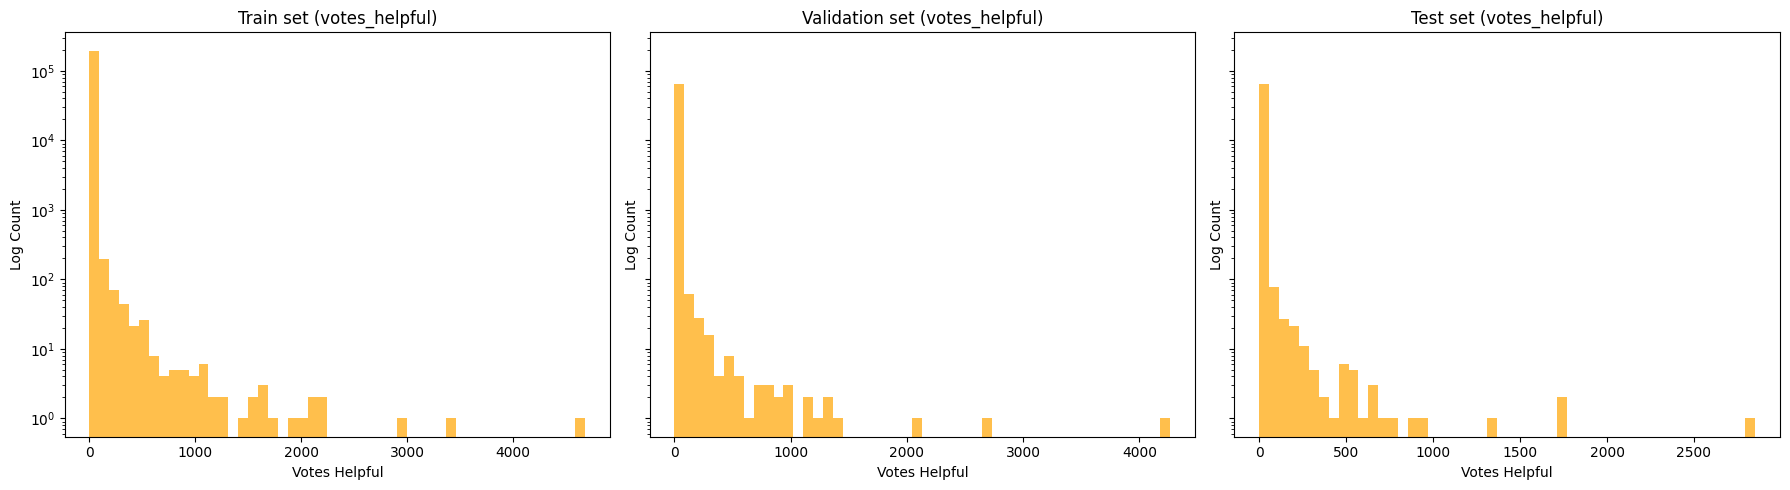

In [11]:
import matplotlib.pyplot as plt

# Plot histograms of review_length_chars for each dataset
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

for ax, split_df, label in zip(
    axes,
    [train_df, val_df, test_df],
    ["Train", "Validation", "Test"]
):
    ax.hist(split_df["review_length_chars"], bins=50, color="steelblue", alpha=0.7)
    ax.set_title(f"{label} set")
    ax.set_xlabel("Review Length (chars)")
    ax.set_ylabel("Count")

plt.tight_layout()
plt.show()

# Plot histograms of votes_helpful for each dataset (log scale for readability)
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

for ax, split_df, label in zip(
    axes,
    [train_df, val_df, test_df],
    ["Train", "Validation", "Test"]
):
    ax.hist(split_df["votes_helpful"], bins=50, color="orange", alpha=0.7, log=True)
    ax.set_title(f"{label} set (votes_helpful)")
    ax.set_xlabel("Votes Helpful")
    ax.set_ylabel("Log Count")

plt.tight_layout()
plt.show()

In [12]:
import plotly.express as px

# Combine train and validation splits to analyze user review counts
user_df = pd.concat([train_df, val_df, test_df])

# Count number of reviews per user (by author.steamid)
user_review_counts = user_df["author.steamid"].value_counts()

# Print how many users have more than 1 review
num_multi_review_users = (user_review_counts > 1).sum()
total_users = user_review_counts.shape[0]
print(f"Number of users with multiple reviews: {num_multi_review_users} / {total_users} ({num_multi_review_users/total_users:.2%})")

# Plot histogram of number of reviews per user (clipped at e.g. 20 for readability)
clip = 20
plt_data = user_review_counts.clip(upper=clip)
fig = px.histogram(plt_data, nbins=clip, title="Distribution of Review Counts per User (Train+Val)",
                   labels={"value": "Number of Reviews", "count": "Number of Users"})
fig.update_layout(xaxis_title="Number of Reviews (per user, capped at 20)", 
                  yaxis_title="Number of Users",
                  bargap=0.2)
fig.show()

Number of users with multiple reviews: 14549 / 306676 (4.74%)
